### Connecting to MySQL and downloading the Songs Table to Python

### First task: Ensure you have downloaded and run the below sql file in MySQL
### 07_(WC SQL) raw_Python_MySQL_songs_record_tasks.sql

In [4]:
# Your working directory
import os
print("Current working directory:", os.getcwd())

Current working directory: C:\PYTHON CLASS\Python Personal Project v2


In [5]:
#Install the mysql module
!pip install sqlalchemy
!pip install mysql-connector-python
!pip install mysqlclient
!pip install PyMySQL
!pip install pyarrow
!pip install fastparquet

#Install the Postgresql module
!pip install psycopg2

In [6]:
!pip freeze

anyio==4.9.0
argon2-cffi==25.1.0
argon2-cffi-bindings==21.2.0
arrow==1.3.0
asttokens==3.0.0
async-lru==2.0.5
attrs==25.3.0
babel==2.17.0
beautifulsoup4==4.13.4
bleach==6.2.0
certifi==2025.7.14
cffi==1.17.1
charset-normalizer==3.4.2
colorama==0.4.6
colorlover==0.3.0
comm==0.2.3
contourpy==1.3.2
cramjam==2.11.0
cufflinks==0.17.3
cycler==0.12.1
debugpy==1.8.15
decorator==5.2.1
defusedxml==0.7.1
et_xmlfile==2.0.0
executing==2.2.0
fastjsonschema==2.21.1
fastparquet==2024.11.0
fonttools==4.59.0
fqdn==1.5.1
fsspec==2025.7.0
greenlet==3.2.4
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.10
ipykernel==6.30.0
ipython==9.4.0
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.7
isoduration==20.11.0
jedi==0.19.2
Jinja2==3.1.6
json5==0.12.0
jsonpointer==3.0.0
jsonschema==4.25.0
jsonschema-specifications==2025.4.1
jupyter==1.1.1
jupyter-console==6.6.3
jupyter-events==0.12.0
jupyter-lsp==2.2.6
jupyter_client==8.6.3
jupyter_core==5.8.1
jupyter_server==2.16.0
jupyter_server_terminals==0.5.3
jupyterlab==4

In [7]:
# Test that pyarrow has been installed
import pyarrow as pa
print("PyArrow version:" , pa.__version__)

PyArrow version: 21.0.0


In [64]:
import mysql.connector as dbconnect
import mysql.connector as mysqlconnector
from sqlalchemy import create_engine
import pandas as pd
from urllib.parse import quote_plus

In [65]:
# Masking my Password
import getpass

# Prompt the user for a password
password = getpass.getpass("Enter your password: ")

Enter your password:  ········


In [66]:
# Connecting to MySQL database normally. (Not advisable again)
db_setup = dbconnect.connect(host='localhost',
                             database='wc_Py_SONGS_Db',
                            user='root',
                             passwd=password)
print("You are now successfully connected to the database!")

You are now successfully connected to the database!


In [67]:
# Ensure the database name is: Py_SONGS_Db
# Ensure the table name is: raw_Py_Songs_tb

query = '''
SELECT *
FROM raw_Py_Songs_tb;
'''

In [68]:
# Executing the sql query using the mysql_engine created
mysql_df = pd.read_sql(query,db_setup)
mysql_df

C:\Users\oyine\AppData\Local\Temp\ipykernel_18612\352962057.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  mysql_df = pd.read_sql(query,db_setup)


,song_id,title,artist,album,year_released,duration,tempo,loudness
0,1,08:00,Intars Busulis,Kino,0,208.16934,140.029,-3.698
1,2,09:02,Aftermath,Tides of Sorrow,0,376.89424,87.006,-4.605
2,3,100%,Cocoa Tea,Kingston Hot,1992,228.96281,115.862,-11.627
3,4,3,Britney Spears,3,2009,465.47546,131.999,-6.278
4,5,3,DJ X-Change,The X-Files 5.0,0,244.08771,136.993,-6.072
...,...,...,...,...,...,...,...,...
9995,9996,Zuo Li Bu An,Tanya Chua,Amphibian,0,254.24934,147.892,-6.217
9996,9997,Zurezko Olerkia,Varios,Luis de Pablo - Zurezko olerkia (Poema de madera),0,168.28036,100.929,-25.431
9997,9998,Zydeco In D-Minor,"Myrick ""Freeze"" Guillory",Nouveau Zydeco,0,300.82567,137.663,-12.574
9998,9999,TRUE,Jim Reeves,The International Jim Reeves/ Good 'N' Country,2000,151.58812,91.632,-14.547


In [69]:
# Close the db_setup connections as it is not advisable
db_setup.close()
print('MySQL Database connection close successfully')

MySQL Database connection close successfully


In [70]:
# Creating connection through MySQL + SQLAlcemy

In [71]:
hostname="localhost"
dbname="wc_py_songs_db"
username="root"
encoded_password = quote_plus(password);
# you can use "mysql+pymysql" or "mysql+mysqldb" instead "mysql+mysqlconnector"
mysql_engine = create_engine(f"mysql+mysqlconnector://{username}:{encoded_password}@{hostname}/{dbname}",
                      pool_recycle=1, pool_timeout=57600).connect()

In [72]:
# Ensure the database name is: Py_SONGS_Db
# Ensure the table name is: raw_Py_Songs_tb

query = '''
SELECT *
FROM raw_Py_Songs_tb;
'''

In [73]:
#Executing the sql query using the mysql_engine created
# Using MySQL + Alchemy works smoothly without warning
mysql_df = pd.read_sql(query,mysql_engine)
mysql_df

,song_id,title,artist,album,year_released,duration,tempo,loudness
0,1,08:00,Intars Busulis,Kino,0,208.16934,140.029,-3.698
1,2,09:02,Aftermath,Tides of Sorrow,0,376.89424,87.006,-4.605
2,3,100%,Cocoa Tea,Kingston Hot,1992,228.96281,115.862,-11.627
3,4,3,Britney Spears,3,2009,465.47546,131.999,-6.278
4,5,3,DJ X-Change,The X-Files 5.0,0,244.08771,136.993,-6.072
...,...,...,...,...,...,...,...,...
9995,9996,Zuo Li Bu An,Tanya Chua,Amphibian,0,254.24934,147.892,-6.217
9996,9997,Zurezko Olerkia,Varios,Luis de Pablo - Zurezko olerkia (Poema de madera),0,168.28036,100.929,-25.431
9997,9998,Zydeco In D-Minor,"Myrick ""Freeze"" Guillory",Nouveau Zydeco,0,300.82567,137.663,-12.574
9998,9999,TRUE,Jim Reeves,The International Jim Reeves/ Good 'N' Country,2000,151.58812,91.632,-14.547


In [74]:
# Converting csv to utf-8 encoding
# mysql_df.to_csv('dbin_songs_data_v2.csv',encoding='utf-8',index=False)

In [75]:
# Close the mysql_engine connections as it is not advisable
mysql_engine.close()
print('MySQL Database connection close successfully')

MySQL Database connection close successfully


In [76]:
# Checking the content datatype of the sql_df
mysql_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   song_id        10000 non-null  int64  
 1   title          10000 non-null  object 
 2   artist         10000 non-null  object 
 3   album          10000 non-null  object 
 4   year_released  10000 non-null  int64  
 5   duration       10000 non-null  float64
 6   tempo          10000 non-null  float64
 7   loudness       10000 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 625.1+ KB


### Perform the Necessary Data Cleaning and Transformation

In [77]:
mysql_df.shape

(10000, 8)

In [78]:
# Checking How many rows and columns in the table
print(f'The number of rows in the table: {mysql_df.shape[0]}')
print(f'The number of columns in the table: {mysql_df.shape[1]}')

The number of rows in the table: 10000
The number of columns in the table: 8


In [79]:
# Checking the number of null/NaN values
print("\nNull values per column:")
mysql_df.isnull().sum()


Null values per column:


song_id          0
title            0
artist           0
album            0
year_released    0
duration         0
tempo            0
loudness         0
dtype: int64

In [80]:
# Extracting the column headers
column_list = list(mysql_df.columns)
print(f"\nColumn headers: {column_list}")


Column headers: ['song_id', 'title', 'artist', 'album', 'year_released', 'duration', 'tempo', 'loudness']


In [81]:
# Checking the unique number of years
unique_years = mysql_df['year_released'].nunique()
print(f"\nUnique number of years: {unique_years}")


Unique number of years: 73


In [82]:
# Checking how many records with year = 0


# Setting the condition
invalid_year = mysql_df['year_released'] == 0


# Counting the year based on the condition
invalid_year_count = invalid_year.sum()
print(f"Records with year = 0: {invalid_year_count}")


Records with year = 0: 5309


In [83]:
# Extracting the first 5 records of invalid year
print("\nFirst 5 invalid year records:")
mysql_df[invalid_year].head()


First 5 invalid year records:


,song_id,title,artist,album,year_released,duration,tempo,loudness
0,1,08:00,Intars Busulis,Kino,0,208.16934,140.029,-3.698
1,2,09:02,Aftermath,Tides of Sorrow,0,376.89424,87.006,-4.605
4,5,3,DJ X-Change,The X-Files 5.0,0,244.08771,136.993,-6.072
10,11,4/20/2002,Pearl Jam,Lost Dogs,0,232.35873,138.291,-12.246
11,12,6 6 2006,Ziggy Marley And The Melody Makers,Hey World,0,335.90812,145.222,-15.889


In [28]:
# Deleting the records with invalid year value
mysql_df = mysql_df[~invalid_year]

# Confirming the deletion
print(f"\nAfter deleting invalid years: {mysql_df.shape[0]} records")



After deleting invalid years: 4691 records


In [29]:
# Checking for invalid value of tempos
print(f"Minimum value for tempos: {mysql_df['tempo'].min()}") 
print(f"Maximum value for tempos: {mysql_df['tempo'].max()}") 

Minimum value for tempos: 0.0
Maximum value for tempos: 258.677


In [30]:
# Checking how many records with tempo <= 0

# Setting the condition
invalid_tempo = mysql_df['tempo'] <= 0

# Counting the year based on the condition
invalid_tempo_count = invalid_tempo.sum()
print(f"Records with tempo <= 0: {invalid_tempo_count}")


Records with tempo <= 0: 12


In [34]:
# Extracting the first 5 records of invalid tempos
mysql_df[['song_id', 'title', 'artist', 'album', 'tempo']][invalid_tempo].head()

,song_id,title,artist,album,tempo
276,277,Afraid Of Change (Tribal Vocal Mix),Casa Bulga,Afraid Of Change,0.0
901,902,bereit,Panzer AG,THIS IS MY BATTLEFIELD,0.0
979,980,Black Market Hell,Aiden,Knives,0.0
1321,1322,Carta De Amor,Egberto Gismonti,Sanfona,0.0
1631,1632,Conker The King,Robin Beanland/Dweezil Zappa/Nile Rodgers/Rabb...,Conker: Live And Reloaded (Original Soundtrack),0.0


In [35]:
# Deleting the records with invalid tempo values
mysql_df.drop(mysql_df[invalid_tempo].index, inplace=True)
print(f"\nAfter deleting invalid tempo: {mysql_df.shape[0]} records")

# Confirming the deletion
remaining_invalid_tempo = (mysql_df['tempo'] <= 0).sum()
print(f"Remaining invalid tempo records: {remaining_invalid_tempo}")


After deleting invalid tempo: 4679 records
Remaining invalid tempo records: 0


C:\Users\oyine\AppData\Local\Temp\ipykernel_18612\1990595433.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mysql_df.drop(mysql_df[invalid_tempo].index, inplace=True)


In [36]:
# Checking for invalid values of loudness
print(f"Minimum value for loudness: {mysql_df['loudness'].min()}") 
print(f"Maximum value for loudness: {mysql_df['loudness'].max()}") 

Minimum value for loudness: -51.643
Maximum value for loudness: 42.0


In [37]:
# Checking how many records with loudness >= 0

# Setting the condition
invalid_loudness = mysql_df['loudness'] >= 0

# Counting the year based on the condition
invalid_loudness_count = invalid_loudness.sum()
print(f"Records with loudness >= 0: {invalid_loudness_count}")

Records with loudness >= 0: 5


In [38]:
# Extracting the first 5 records of invalid loudness
print("\nFirst 5 invalid loudness records:")
mysql_df[['song_id', 'title', 'artist', 'album', 'loudness']][invalid_loudness].head()


First 5 invalid loudness records:


,song_id,title,artist,album,loudness
9,10,1987,2 Minutos,Postal '97,42.000
1409,1410,Check 1_2,EPMD,Out Of Business,36.000
1471,1472,Chuckanut Drive,Power Pill Fist,Kongmanivong,0.566
4122,4123,Intro,Styles P,The Ghost In the Machine,0.000
4156,4157,Is It A Myth?,K'Naan,The Dusty Foot On The Road,4.000


In [39]:
# Deleting the records with invalid year value
mysql_df.drop(mysql_df[invalid_loudness].index, inplace=True)
print(f"\nAfter deleting invalid loudness: {mysql_df.shape[0]} records")

# Confirming the deletion
remaining_invalid_loudness = (mysql_df['loudness'] >= 0).sum()
print(f"Remaining invalid loudness records: {remaining_invalid_loudness}")


After deleting invalid loudness: 4674 records
Remaining invalid loudness records: 0


C:\Users\oyine\AppData\Local\Temp\ipykernel_18612\3177167910.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mysql_df.drop(mysql_df[invalid_loudness].index, inplace=True)


In [40]:
# Checking for accurate data in the dataframe
print("Basic statistics after cleaning:")
mysql_df.describe()

Basic statistics after cleaning:


,song_id,year_released,duration,tempo,loudness
count,4674.000000,4674.000000,4674.000000,4674.000000,4674.000000
mean,5037.142276,1997.141421,238.475217,125.467073,-9.674735
std,2899.776136,11.910012,99.406531,34.718316,5.113862
min,3.000000,1920.000000,7.130980,30.827000,-51.643000
25%,2536.250000,1993.000000,181.139140,98.929500,-12.161250
50%,5057.500000,2001.000000,227.238730,122.398500,-8.587000
75%,7581.250000,2006.000000,278.347300,146.643000,-5.981500
max,9999.000000,2010.000000,1598.197100,258.677000,-1.217000


In [41]:
# checking for the datatypes of each columns
print("\nData types before conversion:")
mysql_df.dtypes


Data types before conversion:


song_id            int64
title             object
artist            object
album             object
year_released      int64
duration         float64
tempo            float64
loudness         float64
dtype: object

In [116]:
# Extracting the column headers
column_list = list(mysql_df.columns) # you can use: mysql_df.column.tolist()
print(f'The column headers: {column_list}')

The column headers: ['song_id', 'title', 'artist', 'album', 'year_released', 'duration', 'tempo', 'loudness']


In [42]:
# Applying the right datatypes to each columns
string_list = ['title', 'artist', 'album']
for header in string_list:
    mysql_df[header] =  mysql_df[header].astype('string')
    
integer_list = ['song_id', 'year_released']
for header in integer_list:
    mysql_df[header] =  mysql_df[header].astype('int16')

float_list = ['duration', 'tempo','loudness']
for header in float_list:
    mysql_df[header] =  mysql_df[header].astype('float16')
    
print("Data types after conversion:")
mysql_df.info()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 4674 entries, 2 to 9998
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   song_id        4674 non-null   int16  
 1   title          4674 non-null   string 
 2   artist         4674 non-null   string 
 3   album          4674 non-null   string 
 4   year_released  4674 non-null   int16  
 5   duration       4674 non-null   float16
 6   tempo          4674 non-null   float16
 7   loudness       4674 non-null   float16
dtypes: float16(3), int16(2), string(3)
memory usage: 191.7 KB


C:\Users\oyine\AppData\Local\Temp\ipykernel_18612\2740943421.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mysql_df[header] =  mysql_df[header].astype('string')
C:\Users\oyine\AppData\Local\Temp\ipykernel_18612\2740943421.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mysql_df[header] =  mysql_df[header].astype('string')
C:\Users\oyine\AppData\Local\Temp\ipykernel_18612\2740943421.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

In [43]:
# Checking the trend of loudness over the years
#create a pivot table from dataframe by modifying the below code but using:
# index= 'year_released', values = loudness, aggfunc='mean'

pd.pivot_table(mysql_df,index='year_released',values='loudness',  aggfunc='mean') 

,loudness
year_released,
1920,-4.953125
1923,-5.265625
1924,-10.703125
1925,-6.707031
1926,-21.671875
...,...
2006,-8.347406
2007,-7.997386
2008,-7.912718


Matplotlib is building the font cache; this may take a moment.


Text(0.5, 1.0, 'Songs average loudness over the years')

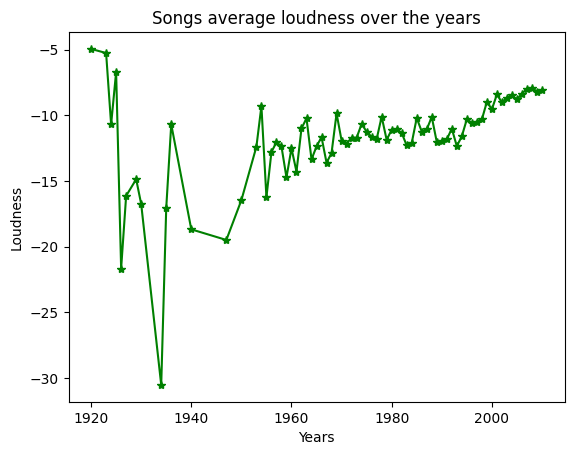

In [119]:
# Using matplotlib, draw a line graph of the year against the average loudness
import matplotlib.pyplot as plt
pivot_table = pd.pivot_table(mysql_df,index='year_released',values='loudness',  aggfunc='mean') 
plt.plot(pivot_table['loudness'],color='green',marker='*',linestyle='-')
plt.xlabel('Years')
plt.ylabel('Loudness')
plt.title('Songs average loudness over the years')

In [44]:
# Checking the number of clean records in our dataframe
mysql_df.shape

(4674, 8)

### Exporting your Cleaned Dataframe into MySQL

In [45]:
table_name = 'clean_py_songs_tb'
hostname="localhost"
dbname="wc_py_songs_db"
username="root"
encoded_password = quote_plus(password);
# you can use "mysql+pymysql" or "mysql+mysqldb" instead "mysql+mysqlconnector"
engine = create_engine(f"mysql+mysqlconnector://{username}:{encoded_password}@{hostname}/{dbname}",
                      pool_recycle=1, pool_timeout=57600).connect()
mysql_df.to_sql(name=table_name, 
        con=engine, 
        if_exists='replace', #there is append, fail
        index=False)

4674

In [46]:
# Confirming the actual records exported
mysql_df.shape[0]

4674

## Data Migration part: Export the mysql_df into Postgresql database 

In [47]:
# Export the mysql_df to PostgreSQL Database (Database name: mysql_pysong_db)
# Please ensure the database(mysql_pysong_db) is already created in Postgresql

table_name = 'clean_py_songs_tb'

In [48]:
import psycopg2 as pgconnect
import pandas as pd
from urllib.parse import quote_plus
from sqlalchemy import create_engine

In [50]:
# Masking my Password
import getpass


# Prompt the user for a password
passwd = getpass.getpass("Enter your password: ")

Enter your password:  ········


In [53]:
# to be deleted

# Exporting the clean dataframe to PostgreSQL
import time

row_total = len(mysql_df)
start_time = time.time()
table_name = 'clean_py_songs_tb'
hostname = "localhost"
dbname = "wc_mysql_pysong_db"
username = "postgres"
port = 5432
encoded_password = quote_plus(passwd)
engine = create_engine(f"postgresql+psycopg2://{username}:{encoded_password}@{hostname}:{port}/{dbname}")
mysql_df.to_sql(table_name, 
                 con=engine, 
                 if_exists="replace", 
                 index=False)
stop_time = time.time()
print(f'The query with {row_total} rows took {round(stop_time-start_time)}secs')

The query with 4674 rows took 1secs


In [54]:
# Exporting dataframe as csv/Excel file
csv_filename = 'cleaned_songs_data.csv'
mysql_df.to_csv(csv_filename, index=False, encoding='utf-8')
print(f"✓ Exported to CSV: {csv_filename}")

✓ Exported to CSV: cleaned_songs_data.csv


In [55]:
# Reading the Exported Songs csv file
csv_df = pd.read_csv(csv_filename)

# Investigating the structure of the imported dataframe
print(f"CSV file shape: {csv_df.shape}")
print("CSV first 5 rows:")
csv_df.head()

CSV file shape: (4674, 8)
CSV first 5 rows:


,song_id,title,artist,album,year_released,duration,tempo,loudness
0,3,100%,Cocoa Tea,Kingston Hot,1992,229.0,115.9,-11.625
1,4,3,Britney Spears,3,2009,465.5,132.0,-6.277
2,6,40,U2,Live From Paris,1992,406.8,146.9,-8.540
3,7,124,Photek,Modus Operandi,1997,421.2,161.8,-10.610
4,8,1492,Scarlet's Remains,Scarlet's Remains,2005,215.9,170.8,-8.040


In [57]:
# Exporting dataframe as csv/Excel file
excel_filename = 'cleaned_songs_data.xlsx'
mysql_df.to_excel(excel_filename, index=False)
print(f"✓ Exported to Excel: {excel_filename}")

# Likely have character issues but the code is valid.

IllegalCharacterError: Castle of KoFW cannot be used in worksheets.

In [58]:
# Reading the Exported Songs Excel file
excel_df = pd.read_excel(excel_filename)

# Likely have character issues
# Investigating the structure of the imported dataframe
print(f"Excel file shape: {excel_df.shape}")


Excel file shape: (4674, 8)


In [141]:
# Exporting dataframe as pickle object
pickle_filename = 'cleaned_songs_data.pkl'
mysql_df.to_pickle(pickle_filename)
print(f"✓ Exported to Pickle: {pickle_filename}")

✓ Exported to Pickle: cleaned_songs_data.pkl


In [142]:
# Reading the Exported Songs pikle file
pickle_df = pd.read_pickle(pickle_filename)

# Investigating the structure of the imported dataframe
print(f"Pickle file shape: {pickle_df.shape}")

Pickle file shape: (4674, 8)


In [144]:
# Exporting dataframe as parquet object, BROTLI provides the best compression
#import pyarrow
import pyarrow
parquet_filename = 'cleaned_songs_data.parquet'
mysql_df.to_parquet(parquet_filename, compression='brotli')
print(f"✓ Exported to Parquet: {parquet_filename}")

✓ Exported to Parquet: cleaned_songs_data.parquet


In [145]:
# Reading the Exported Songs parquet file
parquet_df = pd.read_parquet(parquet_filename)

# Investigating the structure of the imported dataframe
print(f"Parquet file shape: {parquet_df.shape}")


Parquet file shape: (4674, 8)


SyntaxError: invalid syntax (2451092609.py, line 1)